In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import ipywidgets as widgets
from ipywidgets import interact

In [2]:
# 1. Load Data
with open('data/final_models_input/train_dataset.pkl', 'rb') as f:
    train_data = pickle.load(f)
    
with open('data/final_models_input/test_dataset.pkl', 'rb') as f:
    test_data = pickle.load(f)

X_train_raw = train_data['X'] # Shape: (N, 1500, 4)
X_test_raw = test_data['X']

In [7]:
tensor_x = torch.tensor(X_train_raw, dtype=torch.float32)  # [N, T, F]
full_dataset = TensorDataset(tensor_x)

val_size = int(len(full_dataset) * 0.15)
train_size = len(full_dataset) - val_size

train_subset, val_subset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# Extract train data
X_train_subset = torch.stack([train_subset[i][0] for i in range(len(train_subset))])
X_train_subset = X_train_subset.numpy()  # back to numpy for sklearn

N_tr, T, F = X_train_subset.shape

# Flatten time dimension
X_train_flat = X_train_subset.reshape(-1, F)

scaler = MinMaxScaler()
scaler.fit(X_train_flat)

X_train_scaled = scaler.transform(X_train_flat).reshape(N_tr, T, F)
X_train_scaled = torch.tensor(X_train_scaled, dtype=torch.float32)
X_train = X_train_scaled[:, ::5, :]  # Downsample to 300 timesteps

X_val_subset = torch.stack([val_subset[i][0] for i in range(len(val_subset))])
X_val_subset = X_val_subset.numpy()

N_val = X_val_subset.shape[0]
X_val_flat = X_val_subset.reshape(-1, F)

X_val_scaled = scaler.transform(X_val_flat).reshape(N_val, T, F)
X_val_scaled = torch.tensor(X_val_scaled, dtype=torch.float32)
X_val = X_val_scaled[:, ::5, :]  # Downsample to 300 timesteps

train_dataset = TensorDataset(X_train)
val_dataset   = TensorDataset(X_val)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

X_test_flat = X_test_raw.reshape(-1, F)
X_test_scaled = scaler.transform(X_test_flat).reshape(
    X_test_raw.shape[0], T, F
)

X_test_scaled = torch.tensor(X_test_scaled, dtype=torch.float32)
X_test = X_test_scaled[:, ::5, :]  # Downsample to 300 timesteps
test_dataset = TensorDataset(X_test)

print(f"Data Loaded Successfully.")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Data Loaded Successfully.
Train batches: 33
Val batches: 6


In [4]:
SEQ_LEN = 300
N_FEATURES = 4
BATCH_SIZE = 64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Model Architecture

In [5]:
class RecurrentAutoencoder(nn.Module):
    def __init__(self, seq_len, n_features, embedding_dim=64):
        super(RecurrentAutoencoder, self).__init__()
        # Encoder
        self.enc1 = nn.LSTM(n_features, 128, batch_first=True)
        self.enc2 = nn.LSTM(128, embedding_dim, batch_first=True)
        # Decoder
        self.dec1 = nn.LSTM(embedding_dim, 128, batch_first=True)
        self.dec2 = nn.LSTM(128, 128, batch_first=True)
        self.output = nn.Linear(128, n_features)
        self.seq_len = seq_len
        self.embedding_dim = embedding_dim

    def forward(self, x):
        # Encode
        x, _ = self.enc1(x)
        _, (hidden, _) = self.enc2(x)
        latent = hidden[-1]
        
        # Decode
        x = latent.unsqueeze(1).repeat(1, self.seq_len, 1)
        x, _ = self.dec1(x)
        x, _ = self.dec2(x)
        x = self.output(x)
        return x

In [6]:
TRAIN_PATH = 'data/final_models_input/train_dataset.pkl'
SCALER_PATH = 'data/final_models_input/lstm_new_scaler.pkl' # Ensure you have a scaler saved
MODEL_PATH = 'lstm_autoencoder_robust.pth'
STATS_PATH = 'training_error_stats.pkl'

In [11]:
def train_and_profile():
    
    # Train Model
    model = RecurrentAutoencoder(SEQ_LEN, N_FEATURES).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.L1Loss()
    
    print("Training Model...")
    for epoch in range(50):
        model.train()
        for batch in train_loader:
            x = batch[0].to(device)
            recon = model(x)
            loss = criterion(recon, x)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
    torch.save(model.state_dict(), MODEL_PATH)
    
    # 3. STATISTICAL PROFILING (Crucial Step)
    print("Calculating Training Error Statistics per Timestamp...")
    model.eval()
    
    # Get residuals for ALL training data
    # We use a non-shuffled loader for stats
    stat_loader = DataLoader(TensorDataset(torch.FloatTensor(X_train).to(device)), batch_size=BATCH_SIZE)
    
    all_residuals = []
    with torch.no_grad():
        for batch in stat_loader:
            x = batch[0]
            recon = model(x)
            # Residual = |Real - Recon|
            res = torch.abs(x - recon).cpu().numpy()
            all_residuals.append(res)
            
    all_residuals = np.concatenate(all_residuals, axis=0) # Shape: (N, 300, 4)
    
    # Calculate Mean and Std per Timestamp per Feature
    # Shape: (300, 4)
    train_mean = np.mean(all_residuals, axis=0)
    train_std = np.std(all_residuals, axis=0)
    
    # Add a tiny epsilon to std to avoid division by zero
    train_std = train_std + 1e-6
    
    with open(STATS_PATH, 'wb') as f:
        pickle.dump({'mean': train_mean, 'std': train_std}, f)
    with open(SCALER_PATH, 'wb') as f:
        pickle.dump(scaler, f)
            
    print("Model, Scaler, and Stats saved.")
    return train_mean, train_std

Training Model...
Calculating Training Error Statistics per Timestamp...
Model, Scaler, and Stats saved.


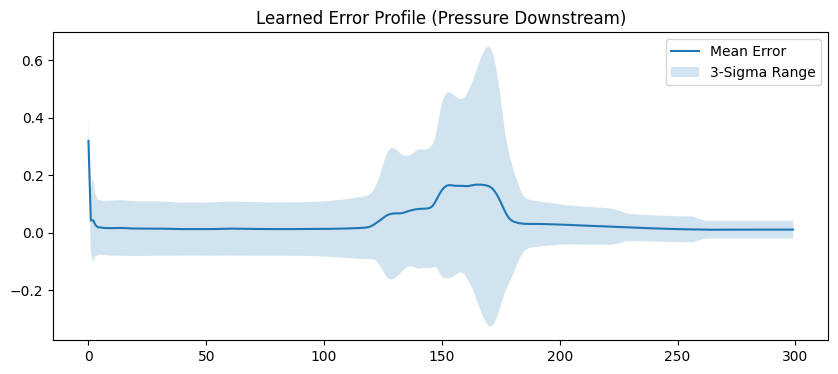

In [12]:
if __name__ == "__main__":
    train_mean, train_std = train_and_profile()
    
    # Visualize the "Normal Error Corridor" for one feature (e.g., Pressure Down)
    plt.figure(figsize=(10, 4))
    plt.plot(train_mean[:, 2], label='Mean Error')
    plt.fill_between(range(300), 
                     train_mean[:, 2] - 3*train_std[:, 2], 
                     train_mean[:, 2] + 3*train_std[:, 2], 
                     alpha=0.2, label='3-Sigma Range')
    plt.title("Learned Error Profile (Pressure Downstream)")
    plt.legend()
    plt.show()

In [ ]:
import hdbscan 

def analyze_test_data():
    # --- LOAD RESOURCES ---
    # Load Real Test Data (Unknown Anomalies)
    TEST_PATH = 'data/final_models_input/train_dataset_with_anomalies.pkl' # REAL TEST SET
    
    with open(TEST_PATH, 'rb') as f:
        data = pickle.load(f)
        X_test_raw = data['X']
        
    with open(SCALER_PATH, 'rb') as f:
        scaler = pickle.load(f)
    with open(STATS_PATH, 'rb') as f:
        stats = pickle.load(f)
        
    mu = stats['mean']  # (300, 4)
    sigma = stats['std'] # (300, 4)
    
    # Preprocess Test Data
    N, T, F = X_test_raw.shape
    X_scaled = scaler.transform(X_test_raw.reshape(-1, F)).reshape(N, T, F)
    X_test = X_scaled[:, ::5, :] # Downsample
    
    # Load Model
    model = RecurrentAutoencoder(SEQ_LEN, N_FEATURES).to(device)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.eval()
    
    # --- 1. GENERATE ANOMALY SCORES ---
    print("Scoring Test Data...")
    tensor_x = torch.FloatTensor(X_test).to(device)
    test_dataset = TensorDataset(tensor_x)

    test_loader = DataLoader(
        test_dataset,
        batch_size=16,   # start small (8–32)
        shuffle=False
    )
    
    all_residuals = []
    residual_features = []

    with torch.no_grad():
        for batch in test_loader:
            x = batch[0].to(device)

            recon = model(x)

            # Absolute residuals
            residual = (x - recon)
            residual_cpu = residual.cpu()
            all_residuals.append(residual_cpu)
            
            residual_np = residual_cpu.numpy()
            for i in range(len(residual_np)):
                r = residual_np[i] # Shape (300, 4)
                
                # --- EXTRACT ERROR SIGNATURE FEATURES ---
                # Instead of clustering 1200 points, we cluster specific error traits
                
                # 1. Mean Error per Sensor (Detects Bias/Offset)
                mean_err = np.mean(r, axis=0) # (4,)
                
                # 2. Max Error per Sensor (Detects Spikes/Hammers)
                max_err = np.max(np.abs(r), axis=0) # (4,)
                
                # 3. Tail Error (Last 50 points) - Specific for Leaks
                tail_err = np.mean(r[-50:, :], axis=0) # (4,)
                
                # Combine into a feature vector (Size 12)
                # This vector describes "The Shape of the Failure"
                feat_vec = np.concatenate([mean_err, max_err, tail_err])
                residual_features.append(feat_vec)

    residuals = torch.cat(all_residuals, dim=0).numpy()
    # X_cluster = np.array(residual_features)

    # CALCULATE Z-SCORES (The Dynamic Anomaly Score)
    # Formula: (|x - x_hat| - mu) / sigma
    # We broaden dimensions of mu/sigma to match batch size
    # Shape: (N, 300, 4)
    z_scores = (residuals - mu) / sigma
    
    # --- 2. ROBUST DECISION RULE ---
    # Rule: Anomaly if ANY feature > 3 sigma for > 15 consecutive steps
    SIGMA_THRESH = 3.0 # Stricter threshold
    TIME_THRESH = 15   # Must persist for 1.5 seconds (at 10Hz downsampled)
    
    detected_indices = []
    root_causes = []
    anomaly_residuals = [] # Store residuals for clustering
    
    feature_names = ["Active Power", "Guide Vane", "Pressure Down", "Pressure Up"]
    
    for i in range(len(z_scores)):
        sample_z = z_scores[i] # (300, 4)
        
        # Check if threshold exceeded
        # Boolean mask: (300, 4)
        exceeds = sample_z > SIGMA_THRESH
        
        # Check consecutive steps per feature
        is_anomalous = False
        cause_idx = -1
        max_deviation = 0
        
        for feat in range(N_FEATURES):
            # Get bool array for this feature
            mask = exceeds[:, feat].astype(int)
            
            # Find longest run of 1s (consecutive errors)
            # A trick to find runs: group by value
            # Or use convolution
            run_lengths = np.diff(np.where(np.concatenate(([0], mask, [0])) != 0)[0])[::2]
            
            if len(run_lengths) > 0 and np.max(run_lengths) >= TIME_THRESH:
                is_anomalous = True
                
                # Determine Root Cause strength
                # We use the Max Z-score achieved by this feature
                feat_max_z = np.max(sample_z[:, feat])
                if feat_max_z > max_deviation:
                    max_deviation = feat_max_z
                    cause_idx = feat
        
        if is_anomalous:
            detected_indices.append(i)
            root_causes.append(feature_names[cause_idx])
            anomaly_residuals.append(residuals[i])
            
    print(f"Detected {len(detected_indices)} anomalies out of {len(X_test)} test samples.")
    
    if len(detected_indices) == 0:
        return

    # --- 3. UNSUPERVISED CLUSTERING (HDBSCAN) ---
    # We want to group anomalies by "Type" without knowing the labels.
    # We use the Residuals (Error Curves) as features.
    
    print("Clustering Anomalies to find patterns...")
    
    # Flatten residuals to (N_anom, 1200) for clustering
    # X_cluster = np.array(anomaly_residuals).reshape(len(anomaly_residuals), -1)
    X_cluster = np.array(residual_features)[detected_indices]
    
    # Use HDBSCAN
    # min_cluster_size: Minimum size to call it a cluster (e.g. 5 samples)
    # clusterer = hdbscan.HDBSCAN(min_cluster_size=5, min_samples=2)
    # cluster_labels = clusterer.fit_predict(X_cluster)
    print("Clustering Anomalies by Error Signature...")

    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=5,
        min_samples=3,
        metric="euclidean"
    )

    cluster_labels = clusterer.fit_predict(X_cluster)
    
    # --- 4. REPORTING & VISUALIZATION ---
    # unique_clusters = np.unique(cluster_labels)
    
    # print("\n=== CLUSTERING RESULTS ===")
    # print(f"Found {len(unique_clusters) - (1 if -1 in unique_clusters else 0)} distinct anomaly types.")
    # print("(-1 indicates 'Noise' or unique outliers that don't fit a pattern)")
    
    # for cluster in unique_clusters:
    #     cluster_mask = cluster_labels == cluster
    #     count = np.sum(cluster_mask)
        
    #     # Determine dominant root cause in this cluster
    #     causes_in_cluster = np.array(root_causes)[cluster_mask]
    #     dominant_cause = max(set(list(causes_in_cluster)), key=list(causes_in_cluster).count)
        
    #     name = "Unknown/Noise" if cluster == -1 else f"Cluster {cluster}"
    #     print(f"{name}: {count} samples | Dominant Signal: {dominant_cause}")
        
    #     # Visualize the "Centroid" of this cluster (Average Error Profile)
    #     if cluster != -1:
    #         mean_residual = np.mean(np.array(anomaly_residuals)[cluster_mask], axis=0)
            
    #         plt.figure(figsize=(10, 4))
    #         for f_idx in range(N_FEATURES):
    #             plt.plot(mean_residual[:, f_idx], label=feature_names[f_idx])
    #         plt.title(f"Average Error Signature: {name} (Cause: {dominant_cause})")
    #         plt.legend()
    #         plt.show()

    unique_labels = np.unique(cluster_labels)
    feature_names = ["Active Power", "Guide Vane", "Pressure Down", "Pressure Up"]
    
    print(f"Found {len(unique_labels)} clusters.")
    
    for lbl in unique_labels:
        if lbl == -1: continue # Noise
        
        # Get samples in this cluster
        mask = cluster_labels == lbl
        cluster_samples = X_cluster[mask]
        
        # Calculate average error profile for this cluster
        # We look at the 'Max Error' part of our feature vector (Indices 4,5,6,7)
        avg_max_err = np.mean(cluster_samples[:, 4:8], axis=0)
        
        # Find dominant sensor
        dom_idx = np.argmax(avg_max_err)
        dom_sensor = feature_names[dom_idx]
        
        print(f"Cluster {lbl}: {np.sum(mask)} samples. Root Cause: {dom_sensor}")
        y_labels = {
            0: "Normal", 
            1: "Seal Leakage", 
            2: "Delayed Closure", 
            3: "Sensor Offset", 
            4: "Sensor Drift",
            5: "Water Hammer",
            6: "Stick-Slip/Jerky",
            7: "PID Hunting",
            8: "Signal Dropout"
        }
        # Optional: Check accuracy against ground truth if available
        if y_labels is not None:
            true_types = y_labels[mask]
            # Find most common actual label
            from scipy.stats import mode
            common = mode(true_types)[0][0] if len(true_types) > 0 else "N/A"
            print(f"  -> Most common actual label: {common}")

    # 4. Visualizing the Clusters (TSNE or PCA)
    # Project the 12D Error Feature space down to 2D
    from sklearn.manifold import TSNE
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    X_tsne = tsne.fit_transform(X_cluster)
    
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=cluster_labels, cmap='tab10', s=10)
    plt.colorbar(scatter, label="Cluster ID")
    plt.title("Map of Anomaly Types (Clustered by Error Signature)")
    plt.xlabel("TSNE 1")
    plt.ylabel("TSNE 2")
    plt.show()

if __name__ == "__main__":
    analyze_test_data()

C:\Users\shrey\AppData\Local\Temp\ipykernel_32600\1823911482.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH, map_location=d

Scoring Test Data...


TypeError: expected Tensor as element 0 in argument 0, but got numpy.ndarray

In [ ]:
# Visualization Utilities: Original vs Reconstruction + Per-Timestamp Loss
import math
from typing import Tuple, Literal
import ipywidgets as widgets
from IPython.display import display, clear_output

feature_names = ["Active Power", "Guide Vane", "Pressure Down", "Pressure Up"]
model = RecurrentAutoencoder(SEQ_LEN, N_FEATURES).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))

def get_dataset_sample(dataset: Literal["train","val","test"], index: int) -> torch.Tensor:
    """Return a single sample tensor of shape [SEQ_LEN, N_FEATURES] from selected set."""
    if dataset == "train":
        x = X_train[index]
    elif dataset == "val":
        x = X_val[index]
    elif dataset == "test":
        x = X_test[index]
    else:
        raise ValueError("dataset must be one of 'train','val','test'")
    return torch.as_tensor(x, dtype=torch.float32)

def get_reconstruction(x: torch.Tensor, model: nn.Module) -> torch.Tensor:
    """Run provided `model` to get reconstruction for one sample. Input x: [SEQ_LEN, N_FEATURES]."""
    assert isinstance(model, nn.Module), "`model` must be a torch.nn.Module"
    model.eval()
    with torch.no_grad():
        x_b = x.unsqueeze(0).to(device)  # [1, T, F]
        recon_b = model(x_b)             # [1, T, F]
    return recon_b.squeeze(0).cpu()

def plot_original_vs_recon(x: torch.Tensor, recon: torch.Tensor, title_prefix: str = ""):
    """Plot original and reconstruction for each feature over time."""
    T = x.shape[0]
    fig, axes = plt.subplots(nrows=N_FEATURES, ncols=1, figsize=(10, 8), sharex=True)
    time = np.arange(T)
    for i in range(N_FEATURES):
        axes[i].plot(time, x[:, i].numpy(), label="Original", linewidth=1.5)
        axes[i].plot(time, recon[:, i].numpy(), label="Reconstruction", linewidth=1.2)
        axes[i].set_ylabel(feature_names[i])
        axes[i].grid(True, alpha=0.3)
    axes[-1].set_xlabel("Timestamp (downsampled)")
    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right")
    fig.suptitle(f"{title_prefix} Original vs Reconstruction")
    plt.tight_layout()
    plt.show()

def plot_per_timestamp_loss(x: torch.Tensor, recon: torch.Tensor, reduction: Literal["mean","max","sum"] = "mean"):
    """Plot per-timestamp loss across features using absolute residuals."""
    residual = torch.abs(x - recon)  # [T, F]
    if reduction == "mean":
        loss_t = residual.mean(dim=1).numpy()
        ylabel = "Mean |x - x_hat| across features"
    elif reduction == "max":
        loss_t = residual.max(dim=1).values.numpy()
        ylabel = "Max |x - x_hat| across features"
    elif reduction == "sum":
        loss_t = residual.sum(dim=1).numpy()
        ylabel = "Sum |x - x_hat| across features"
    else:
        raise ValueError("reduction must be one of 'mean','max','sum'")
    T = residual.shape[0]
    plt.figure(figsize=(10, 3))
    plt.plot(np.arange(T), loss_t, color="tab:red")
    plt.title("Per-Timestamp Reconstruction Loss")
    plt.ylabel(ylabel)
    plt.xlabel("Timestamp (downsampled)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def visualize_sample(model: nn.Module, dataset: Literal["train","val","test"], index: int, loss_reduction: Literal["mean","max","sum"] = "mean", save_figures: bool = False, save_prefix: str = "figures/sample"):
    """Convenience function: fetch sample, reconstruct with `model`, and plot both visualizations.
    - model: torch.nn.Module autoencoder used for reconstruction
    - dataset: which set to pull from
    - index: sample index
    - loss_reduction: mean/max/sum across features per timestamp
    - save_figures: optionally save the two figures
    - save_prefix: base path for saved files (without extension)
    """
    # Fetch sample and reconstruction
    x = get_dataset_sample(dataset, index)
    recon = get_reconstruction(x, model)

    # Plot comparisons
    title_prefix = f"[{dataset} idx={index}]"
    plot_original_vs_recon(x, recon, title_prefix=title_prefix)
    plot_per_timestamp_loss(x, recon, reduction=loss_reduction)

    # Optional save
    if save_figures:
        try:
            import os
            os.makedirs(os.path.dirname(save_prefix), exist_ok=True)
            # Recreate figures for saving to avoid empty saves after show()
            # Original vs Reconstruction
            T = x.shape[0]
            fig, axes = plt.subplots(nrows=N_FEATURES, ncols=1, figsize=(10, 8), sharex=True)
            time = np.arange(T)
            for i in range(N_FEATURES):
                axes[i].plot(time, x[:, i].numpy(), label="Original", linewidth=1.5)
                axes[i].plot(time, recon[:, i].numpy(), label="Reconstruction", linewidth=1.2)
                axes[i].set_ylabel(feature_names[i])
                axes[i].grid(True, alpha=0.3)
            axes[-1].set_xlabel("Timestamp (downsampled)")
            handles, labels = axes[-1].get_legend_handles_labels()
            fig.legend(handles, labels, loc="upper right")
            fig.suptitle(f"{title_prefix} Original vs Reconstruction")
            plt.tight_layout()
            fig.savefig(f"{save_prefix}_orig_vs_recon.png", dpi=150)
            plt.close(fig)

            # Per-timestamp loss
            residual = torch.abs(x - recon)
            if loss_reduction == "mean":
                loss_t = residual.mean(dim=1).numpy()
            elif loss_reduction == "max":
                loss_t = residual.max(dim=1).values.numpy()
            else:
                loss_t = residual.sum(dim=1).numpy()
            fig2 = plt.figure(figsize=(10, 3))
            plt.plot(np.arange(T), loss_t, color="tab:red")
            plt.title("Per-Timestamp Reconstruction Loss")
            plt.ylabel(loss_reduction.upper())
            plt.xlabel("Timestamp (downsampled)")
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            fig2.savefig(f"{save_prefix}_loss.png", dpi=150)
            plt.close(fig2)
            print(f"Saved figures to {save_prefix}_*.png")
        except Exception as e:
            print(f"Failed to save figures: {e}")

# Interactive widget (passes global `model`)
dataset_dd = widgets.Dropdown(options=["train","val","test"], value="test", description="Dataset:")
index_slider = widgets.IntSlider(value=0, min=0, max=max(len(X_train)-1, len(X_val)-1, len(X_test)-1), step=1, description="Index:")
reduction_dd = widgets.Dropdown(options=["mean","max","sum"], value="mean", description="Loss:")
save_chk = widgets.Checkbox(value=False, description="Save Figures")
save_prefix_tb = widgets.Text(value="figures/sample", description="Save Prefix:")

def on_update(model: nn.Module, dataset, index, loss_reduction, save_figures, save_prefix):
    clear_output(wait=True)
    display(ui)
    assert 'model' in globals(), "Global `model` is not defined. Load or train the model first."
    visualize_sample(model, dataset, index, loss_reduction, save_figures, save_prefix)

ui = widgets.VBox([dataset_dd, index_slider, reduction_dd, widgets.HBox([save_chk, save_prefix_tb])])
out = widgets.interactive_output(on_update, {
    'model' : widgets.fixed(model),
    'dataset': dataset_dd,
    'index': index_slider,
    'loss_reduction': reduction_dd,
    'save_figures': save_chk,
    'save_prefix': save_prefix_tb
})

display(ui, out)

C:\Users\shrey\AppData\Local\Temp\ipykernel_32600\514153851.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH, map_location=dev

Output()